   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

/tmp/ipykernel_884/1611228460.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_884/1611228460.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

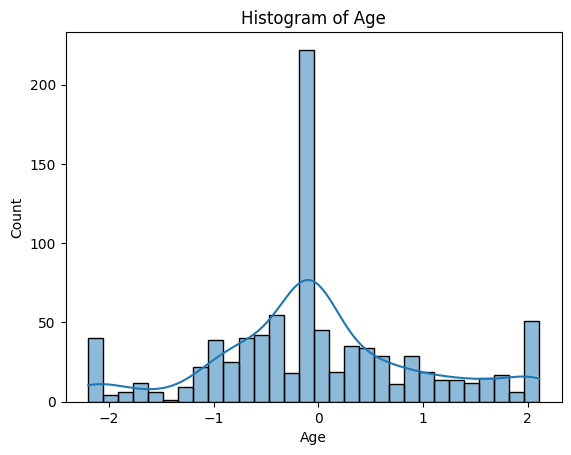

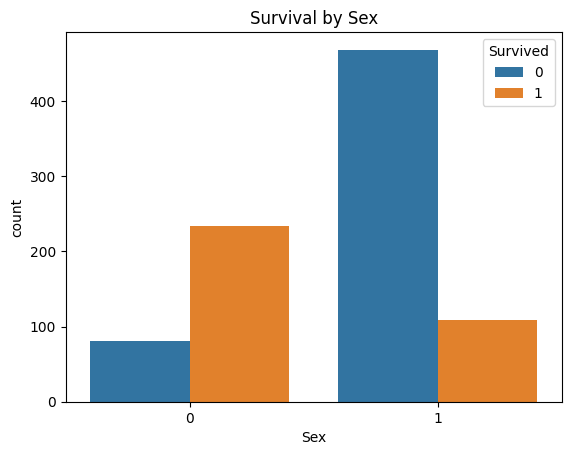

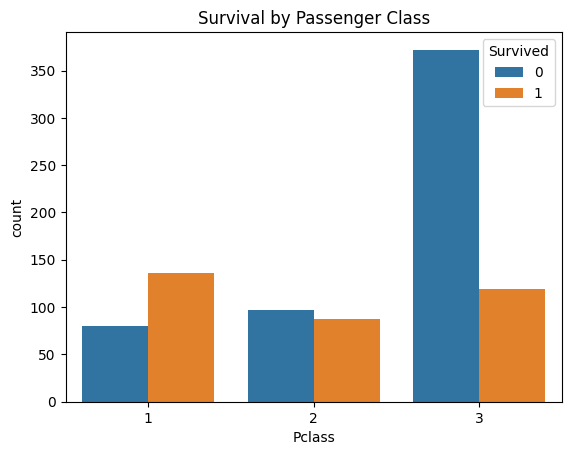

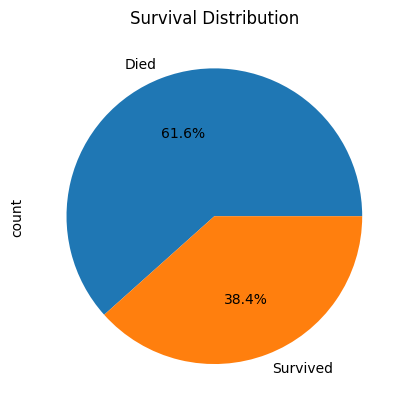

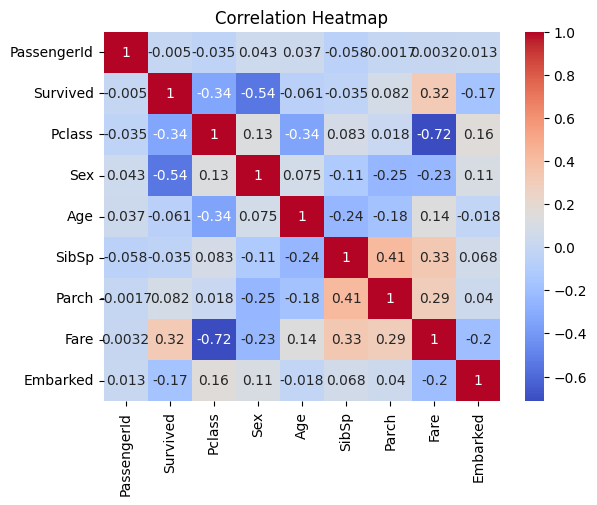


✅ Clean Titanic dataset saved as titanic_clean.csv


In [2]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1) Load dataset
df = pd.read_csv("/content/Titanic.csv")
print(df.head())

# 2) Check missing values
print(df.isnull().sum())

# 3) Fill missing values (basic imputation)
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin (too many missing)
if "Cabin" in df.columns:
    df.drop(columns=["Cabin"], inplace=True)

# 4) Encode categorical variables
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])              # male=1, female=0
df["Embarked"] = le.fit_transform(df["Embarked"])    # simple labels for beginners

# 5) Outlier detection & capping (IQR) on Age & Fare
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

df["Age"] = cap_outliers(df["Age"])
df["Fare"] = cap_outliers(df["Fare"])

# 6) Scale numeric columns (simple)
scaler = StandardScaler()
df[["Age","Fare"]] = scaler.fit_transform(df[["Age","Fare"]])

# -------------------------------
# 6.1) DESCRIPTIVE STATISTICS 📊
# -------------------------------
print("Mean:\n", df[["Age","Fare"]].mean())
print("\nMedian:\n", df[["Age","Fare"]].median())
print("\nMode:\n", df[["Age","Fare"]].mode().iloc[0])
print("\nStandard Deviation:\n", df[["Age","Fare"]].std())
print("\nMinimum:\n", df[["Age","Fare"]].min())
print("\nMaximum:\n", df[["Age","Fare"]].max())

# 7) Visualizations
# (a) Histogram of Age
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Histogram of Age")
plt.show()

# (b) Survival by Sex (bar chart)
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()

# (c) Survival by Passenger Class (bar chart)
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

# (d) Survival distribution (pie chart)
df["Survived"].value_counts().plot.pie(autopct="%1.1f%%", labels=["Died","Survived"])
plt.title("Survival Distribution")
plt.show()

# (e) Correlation heatmap (numeric only)
numeric_df = df.select_dtypes(include=["int64","float64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 8) Save clean dataset
df.to_csv("titanic_clean.csv", index=False)
print("\n✅ Clean Titanic dataset saved as titanic_clean.csv")